# Coupled flow and transport in a fractured porous medium
Here we show how to set up a simulation of coupled flow and transport in a fractured porous media using the multiphysics simulation framework in PorePy. The tutorial covers how to specify:
* The geometry of the fracture network and the computational domain;
* Boundary and initial conditions.
* Specific constitutive laws for 
* Parameters for mesh size control;
* Simulation time etc.

Although the tutorial in one sense aims to be self-contained, we will make frequent references to other tutorials in PorePy proper, where more details are provided. For instance, it may be advisable to read through the PorePy tutorial on single phase flow before reading further here.

**A word of caution**: The multiphysics models in PorePy make heavy use of Python mixins (for readers familiar with object oriented programming, mixins can crudely be thought of as inheritance, though there are important caveats in that mental model). While this is a powerful technology that allows for code reuse and flexibility in simulation setup, it will lead to unexpected behavior (typically the calling of the wrong version of a polymorphic method). The below code is safe to use, but before composing simulation classes from scratch, it is highly advisable to read up on mixins - see for instance [this reference](https://www.thedigitalcatonline.com/blog/2020/03/27/mixin-classes-in-python/) for more information.

# Setting up the simulation class

## Design philosophy
PorePy comes with a set of complete multiphysics models. By themselves these base models are minimal setups (typically, they will involve a 2d domain with four cells with homogeneous boundary and initial conditions) that can be extended. Such extensions can take three forms:
1. By picking methods and classes from a library that ships with PorePy. These classes and methods will typically represent constitutive relations.
2. By setting parameters that will be used by the model.
3. By overriding methods in the base model.

To understand the architecture and the workflow of the multiphysics models, it can be useful to think of them as being [frameworks rather than libraries](https://www.geeksforgeeks.org/software-engineering/software-framework-vs-library/), in the sense that the simulation will invoke certain methods and the user is free to redefine how these methods will behave. However, PorePy does not follow this principle strictly and it may not be fruitfull to pursue this model too far.


## Overriding methods 
For technical reasons, it is necessary to first override methods (through defining mixin classes), then picking constitutive laws, and finally set parameters for the models. 

We start by importing PorePy, as well as numpy and the Path class from pathlib:

In [1]:
import porepy as pp
import numpy as np
from pathlib import Path

# Import pprint module for pretty-printing of data structures
from pprint import pprint

### Geometry
We will specify the simulation setup through a series of mixin classes. First, we import the fracture network geometry from a csv file and also define the domain.

Points to note:
* How to read fractures and a domain from a CSV file and feed them into the the multiphysics model.
* More generally, which methods to override to set fractures and domain.

In [2]:
# NOTE: Mixin classes are defined without constructors, and ideally without use of
# inheritance. The former is by design, the latter is very much on purpose.
class MyGeometry:

    def set_fractures(self):
        # The first line in the csv file specifies the domain, so we skip it when
        # reading the fracture data.
        data = np.genfromtxt(Path('fractures.csv'), delimiter=',', skip_header=1)
        fractures = []
        for row in data:
            f = pp.LineFracture(row.reshape((2, -1), order="F"))
                
            fractures.append(f)
        self._fractures = fractures

    def set_domain(self):
        # Read only the first line of the csv file.
        data = np.genfromtxt(Path('fractures.csv'), delimiter=',', max_rows=1)
        self._domain = pp.Domain({"xmin": data[0], "ymin": data[1], "xmax": data[2], "ymax": data[3]})

    

### Boundary conditions
By default, PorePy assign no-flow (homogeneous Neumann) conditions for flow and transport. We therefore only need to specify the conditions along boundaries where other conditions apply. In our case, we will (arbitrarily) set the pressure at the left (west) and right (east) boundaries to 2MPa and 1MPa, respectively, and leave the top and bottom boundaries untouched.

Points to note:
* The type and numerical values for boundary conditions are set by overriding two different methods.
* By default, boundary conditions will be of Neumann type.
* By default, boundary conditions will have the numerical value zero (independent of the type of the condition).
* Setting boundary conditions for mass flow requires some care - see the flow chart (!) in the PorePy tutorial on boundary conditions.
* Numerical values for parameters, boundary and initial values etc. should always be set using the unit conversion system.

In [3]:
class MyBoundaryConditions:

    def bc_type_darcy_flux(self, sd: pp.Grid) -> pp.BoundaryCondition:
        """Boundary condition type (not values!) for Darcy flux.
        """
        # Get hold of the object that describes the sides of the domain. This has
        # attributes north, south, east, and west, which can be used to index faces
        # at the respective sides of the domain.
        domain_sides = self.domain_boundary_sides(sd)
        # Define boundary condition on faces. Dirichlet conditions on the east and west
        # sides - the north and south will be assigned Neumann conditions by default.
        return pp.BoundaryCondition(sd, domain_sides.south + domain_sides.north, "dir")

    def bc_values_pressure(self, bg: pp.BoundaryGrid) -> np.ndarray:
        """Boundary condition values for Darcy flux.
        """
        # Fetch the sides of the domain.
        domain_sides = self.domain_boundary_sides(bg)
        # The return value is an array of zeros with the size of the number of cells in
        # the boundary grid (which is equivalent to the number of boundary faces in the
        # original grid). 
        values = np.zeros(bg.num_cells)
        # The multiphysics models have a system for automatic unit conversion, which can
        # be set up at the configuration step (below). It is good practice to
        # consistently use the conversion system, as in the code below.
        south_value = self.units.convert_units(1 * pp.MEGA * pp.PASCAL, "Pa")
        south_value = self.units.convert_units(1 * pp.PASCAL, "Pa")
        north_value = 2 * south_value
        # Set values, return.
        values[domain_sides.north] = north_value
        values[domain_sides.south] = south_value
        return values

    def bc_type_fluid_flux(self, sd: pp.Grid) -> pp.BoundaryCondition:
        """Boundary condition type for the density-mobility product.
        """
        domain_sides = self.domain_boundary_sides(sd)
        return pp.BoundaryCondition(sd, domain_sides.south + domain_sides.north, "dir")

    def bc_values_overall_fraction(
        self, component: pp.Component, bg: pp.BoundaryGrid
    ) -> np.ndarray:
        """Define non-trivial inflow of the tracer component on the inlet (west)."""

        z = np.zeros(bg.num_cells)

        assert component.name == "tracer", "Only the tracer is independent."

        # Set the tracer concentration to 0.5
        domain_sides = self.domain_boundary_sides(bg)
        # Strictly speaking, we need not convert a dimensionless quantity.
        z[domain_sides.north] = self.units.convert_units(0.5, "-")
        return z


### Initial conditions
Initial conditions are set up by overriding respective methods.

Points to note:
* How to set initial conditions for the primary variables.
* How to access and use information on the grid geometry inside methods in the multiphysics model.

In [4]:
class MyInitialConditions:

    def initial_pressure(self, g: pp.Grid) -> np.ndarray:
        """Initial condition for pressure.
        """
        # Set the initial pressure equal to the right (outlet) boundary condition.
        initial_value = self.units.convert_units(1 * pp.MEGA * pp.PASCAL, "Pa")
        initial_value = self.units.convert_units(1 * pp.PASCAL, "Pa")
        return np.full(g.num_cells, initial_value)

    def initial_overall_fraction(self, component: pp.Component, g: pp.Grid) -> np.ndarray:
        """Initial condition for the overall fraction of the tracer component.
        """
        # For illustration, we let the initial condition be a function of the spatial
        # coordinates of the cell centers. Note that there are no checks on the
        # dimension of the grid - the code is valid for the 2d matrix grid as well as
        # for 1d fracture and 0d intersection grids.
        x = g.cell_centers[0, :]
        y = g.cell_centers[1, :]

        # Get hold of the bounding box of the domain. This is an attribute of the
        # multiphysics model.
        box = self.domain.bounding_box
        x_min = box["xmin"]
        x_max = box["xmax"]
        y_min = box["ymin"]
        y_max = box["ymax"]

        # Relative coordinates in the domain, between 0 and 1.
        x_r = (x - x_min) / (x_max - x_min)
        y_r = (y - y_min) / (y_max - y_min)

        # Arbitrary function of the coordinates - should be between 0 and 1 to be a
        # valid overall fraction.
        values = (0.1 * x_r + 0.2 * x_r * y_r)
        # values = 0.5 * np.ones(g.num_cells)  # --- IGNORE ---
        return values

### Specifying fluid components
The final method to override is the definition of the components present in the simulations: There will be a reference component which we populate with water properties and a tracer component.

In [5]:
class TracerFluid:
    def get_components(self) -> Sequence[pp.FluidComponent]:
        """Mixed in method defining water as the reference component and a simple
        tracer as the second component."""

        component_1 = pp.FluidComponent(**pp.applications.material_values.fluid_values.water)
        component_2 = pp.FluidComponent(name="tracer")
        return [component_1, component_2]

    

## Composing the multiphysics model
Having overriden the methods that we want, the next step is to compose the full multiphysics model. This is a critical step where the traps of mixins and inheritance must be avoided. Put shortly, the order in which the classes are added in the composition is key - to see this, try to move the base model to the top of the below composition and see what happens.

Though visualization is best done in Paraview, we augment a method called after convergence of the nonlinear solver to give a plot (using matplotlib) of the tracer distribution. This method is convenient for small problems in 2d, but scales poorly with the numeber of cells and generally works hopelessly in 3d.

Points to note:
* Be careful with the order of the mixin classes.
* A simple way to plot solutions for 2d simulations (on grids that are not too large)

In [6]:
class MySimulationModel(
    # First add the mixin classes with overridden methods that we defined above
    MyGeometry,
    MyBoundaryConditions,
    MyInitialConditions,
    TracerFluid,
    # Next add some selected constitutive laws:
    # Set the permeability of the fractures according to the cubic law. The aperture
    # value will be specified below.
    pp.constitutive_laws.CubicLawPermeability,
    # We will use the single-phase flow model as our base. This must be extended by
    # variables representing the tracer, and by appropriate mass balance equations, as
    # is done in the next two lines.
    pp.compositional.compositional_mixins.CompositionalVariables,
    pp.models.compositional_flow.BoundaryConditionsMulticomponent,
    pp.models.compositional_flow.ComponentMassBalanceEquations,
    # Finally the base model.
    pp.SinglePhaseFlow
):
    # No need to do anything here, though we may choose to do so. Specifically, there is
    # no constructor (init), as this is already contained in the base model.

    def after_nonlinear_convergence(self) -> None:
        """Override to plot progress in tracer distribution."""

        # NOTE: Calling the super method is critical here. The change that we implement
        # is an addition, not a replacement.
        super().after_nonlinear_convergence()
        minutes = int(self.time_manager.time / pp.MINUTE)
        title = f"Tracer distribution after {minutes} minutes"
        pp.plot_grid(
            self.mdg,
            "z_tracer",
            figsize=(10, 8),
            linewidth=1.2,
            title=title,
            plot_2d=True,
        )    


# Running a simulation
Having defined the full simulation class, the next step is to create a simulation object and use it to run the simulation. To that end we need to, or can, introduce a few further objects.

## Specifying solid constants. 
First, we should specify values for rock properties, such as permeability and porosity, through a SolidConstants object. It is possible to initialize this object with 'typical values' for certain rock types, as shown for granite below. We also augment the values to include an aperture value through the parameter residual_aperture (the meaning of 'residual' is not clear in this context, but it will be so for simulations with dynamic permeability, e.g. due to fracture deformation). 

Points to note:
* The SolidConstants object is one way of modifying the numerical values of constitutive laws. For instance, the permeability value we set here will be picked up by the CubicLawPermeability mixin class we added above and assigned as the permeability value in the rock matrix. Similarly, the residual_aperture will be used to compute the fracture permeability.
* As can be seen from the below print-out, the constants object contains fields that are not needed for a flow and transport simulation. Their inclusion is motivated from other types of physics, such as rock deformation.
* The default values of the SolidConstants objects tend to be either 1.0 or 0.0. These can be considered neutral (for a mathematician) values, but clearly, it is important to inspect such defaults before starting a time demanding simulation.

In [7]:
# Initialize the solid constants object.
solid_constants = pp.SolidConstants(**pp.solid_values.granite | {"residual_aperture": 1e-3})
# Print the constant values in SI units. 
pprint(solid_constants.constants_in_SI)


{'biot_coefficient': 0.47,
 'density': 2683.0,
 'dilation_angle': 0.0,
 'fracture_gap': 0.0,
 'fracture_normal_stiffness': 1.0,
 'fracture_tangential_stiffness': -1.0,
 'friction_coefficient': 0.6,
 'lame_lambda': 7020826106,
 'maximum_elastic_fracture_opening': 0.0,
 'normal_permeability': 1.0,
 'permeability': 5e-18,
 'porosity': 0.013,
 'residual_aperture': 0.001,
 'shear_modulus': 14854721950.0,
 'skin_factor': 0.0,
 'specific_heat_capacity': 720.7,
 'specific_storage': 4.74e-10,
 'thermal_conductivity': 3.1,
 'thermal_expansion': 9.66e-06,
 'well_radius': 0.1}


## Setting the unit conversion object
Next, we set the units object that we referred to at various places above. Poorly scaled systems may lead to bad conditioning of linear systems, which again is associated with (among other problems) stagnation in Newton's method. Choosing the right units can to some extent be aided by analysis of typical magnitudes of the quantities involved in the system, but it is also something of an art that requires expeirence backed up with trial and error.

In this case, it turned out that changing the scale for length was beneficial for non-linear convergence.

In [8]:
units = pp.Units(m=1e3, kg=1)


## Time control
Management of time is for the moment controlled by an object of the TimeManager class. This can be set up as follows:

In [9]:
# Set a list of time points at which we want to save the solution.
schedule = np.arange(10) * pp.HOUR
# Initial time step, used for the first steps until the solver can estimate a good time
# step size.
dt_init = 1 * pp.HOUR
# Set maximum and minimum time step sizes. The solver will adapt the time step size
# within these limits based on the convergence behavior of the nonlinear solver. They
# may not be very important for the current setup, which is mainly linear, but they can
# be crucial for more complex problems.
dt_max = schedule[-1] - schedule[0]  # The maximum time step should be smaller than the total simulation time.
dt_min = schedule[1] - schedule[0]  # The minimum time step should be smaller than the first time interval in the schedule.

time_manager = pp.TimeManager(
    schedule=schedule,
    dt_init=dt_init,
    dt_min_max=(dt_min, dt_max),
    constant_dt=True
)

## Simulation parameters
Finally, the various datastructures are gathered in a dictionary to be passed to the simulation object.

In [10]:
model_parameters = {
    # Cell size in m. See the PorePy tutorial on meshing for details on mesh size
    # control.
    "meshing_arguments": {"cell_size": 40.0},
    # Grid type. For this fracture geometry the only option is a simplex grid.
    "grid_type": "simplex",
    "time_manager": time_manager,
    "units": units,
    "materials": {"solid": solid_constants},
}

# Also generate a dictionary of parameters for the numerical methods. The current
# problem is linear and there is no need for setting non-default parameters, but for
# more complex problems the choice of numerical methods and their parameters can be
# crucial for the performance of the solver.
numerical_parameters = {        "nl_max_iterations": 80,
        "nl_convergence_inc_atol": 1e-5,
        "nl_convergence_res_atol": 1e-5,}

## Running the simulation
Finally we can run the simulation. 

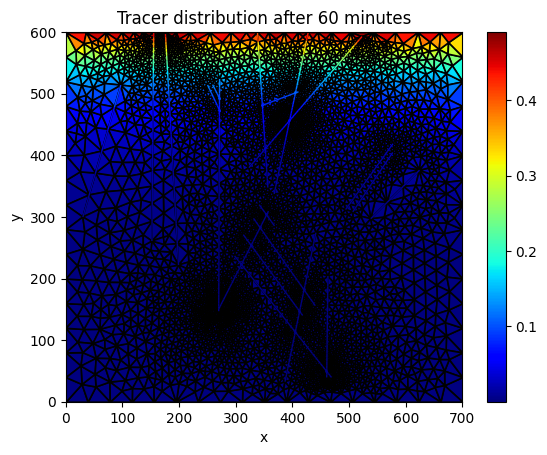

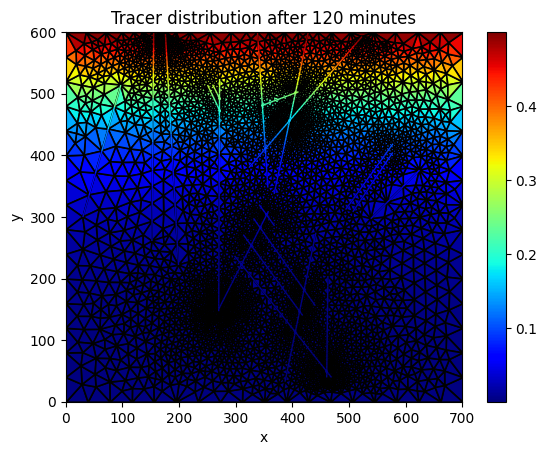

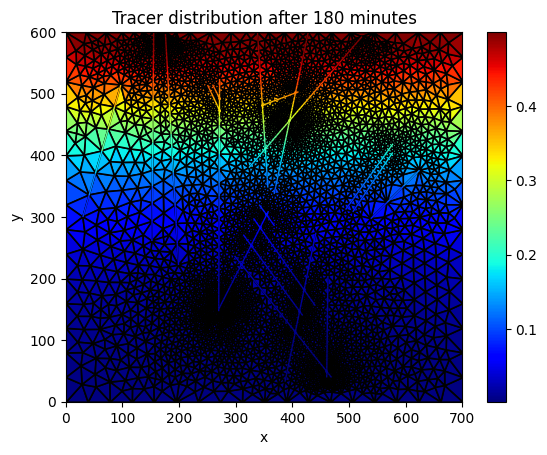

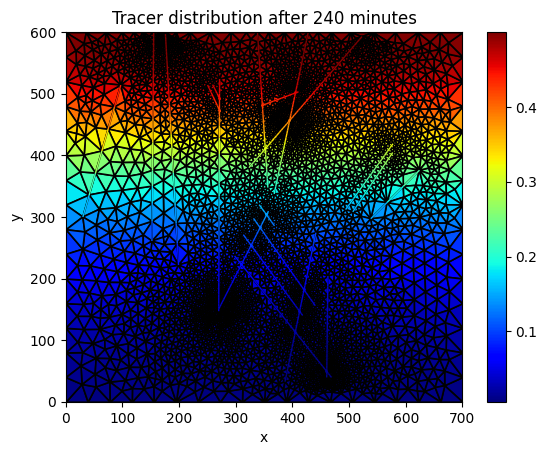

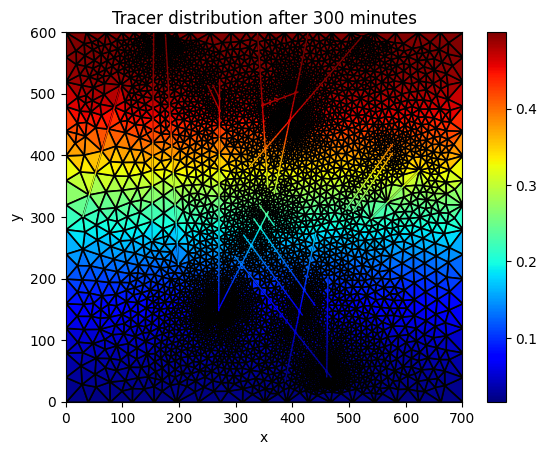

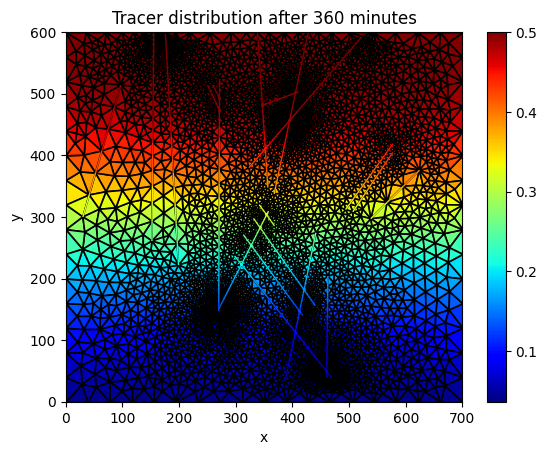

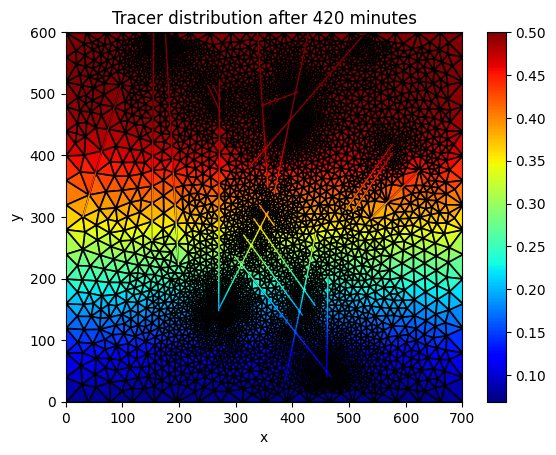

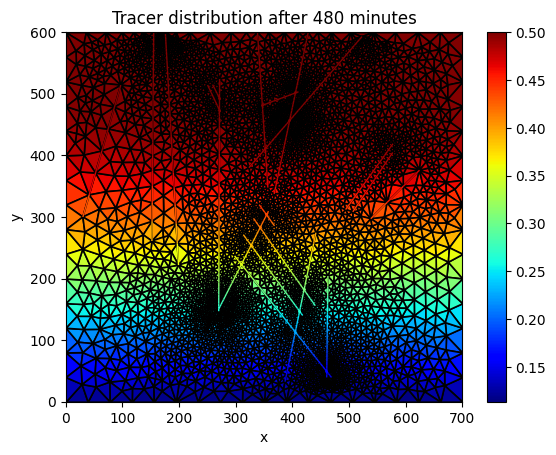

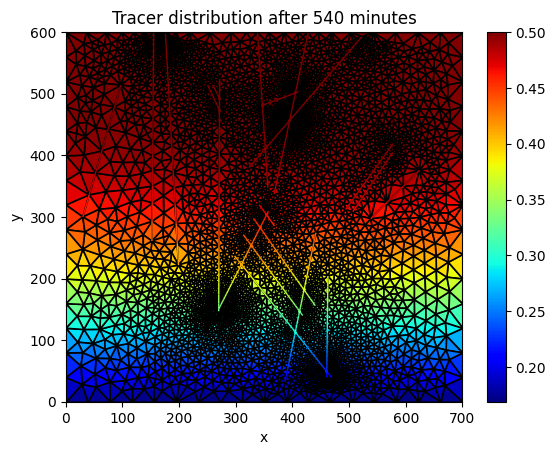

In [11]:
# Create the simulation model object.
model = MySimulationModel(model_parameters)
# Run the simulation
pp.run_time_dependent_model(model, numerical_parameters)

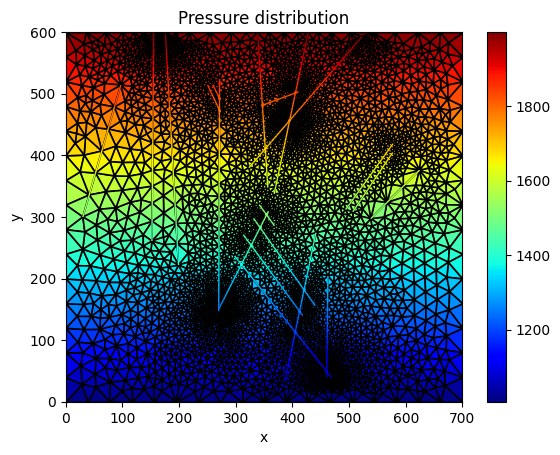

In [13]:
pp.plot_grid(model.mdg, 'pressure', figsize=(10, 8), linewidth=1.2, title="Pressure distribution", plot_2d=True)

In [14]:
model.mdg

Mixed-dimensional grid containing 35 grids and 48 interfaces.
Maximum dimension present: 2 
Minimum dimension present: 0 
1 grids of dimension 2 with in total 7570 cells
20 grids of dimension 1 with in total 378 cells
14 grids of dimension 0 with in total 14 cells
20 interfaces between grids of dimension 2 and 1 with in total 756 mortar cells.
28 interfaces between grids of dimension 1 and 0 with in total 56 mortar cells.